<a href="https://colab.research.google.com/github/joyumoh/Titanic-Prediction-Model/blob/main/Copy_of_Titanic_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INTRODUCTION**

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, I want to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

**IMPORTATION OF LIBRARIES**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train-test split
from sklearn.model_selection import train_test_split

In [2]:
# Load dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

# Display first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**UNDERSTANDING THE DATASET**

In [3]:
# Rows and columns
print(df.shape)

(891, 12)


In [4]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


DATA **CLEANING**

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Missing values count
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [10]:
# Filling missing Age
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
# Filling missing Cabin
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [12]:
# Filling missing Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
# Checking the cleaned dataset
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**FEATURE ENGINEERING**

In [14]:
# Creating Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [15]:
# Creating IsAlone Feature
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

In [16]:
# Extracting Passenger Title From Name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [17]:
# Simplifying Rare Titles
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
     'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)

df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [18]:
# Extract Deck from Cabin
df['Deck'] = df['Cabin'].str[0]

# Fill missing Deck values
df['Deck'] = df['Deck'].fillna('Unknown')

In [19]:
# Create Ticket Group Size
df['TicketGroup'] = df.groupby('Ticket')['Ticket'].transform('count')

In [20]:
# Drop Raw Columns
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

**ENCODING CATEGORICAL VARIABLES**

In [21]:
# Encoding Using One-Hot Endcoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title', 'Deck'], drop_first=True)

**EXPLORATORY DATA ANALYSIS**

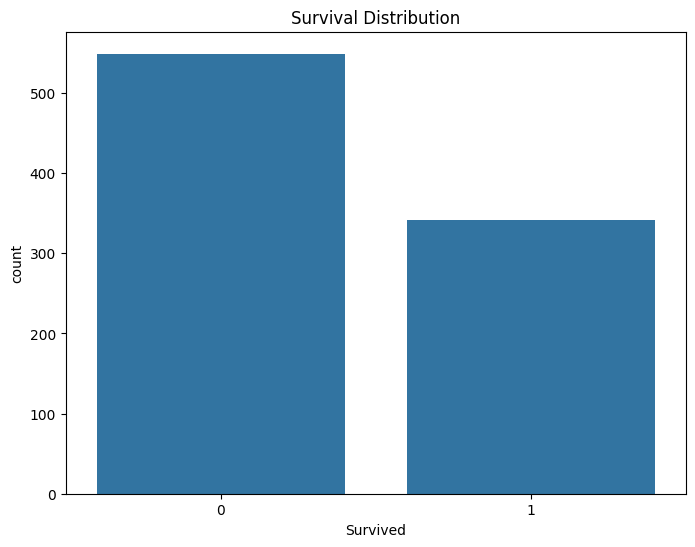

In [22]:
# Survival Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=df)

plt.title("Survival Distribution")
plt.show()

This plot shows the distribution of survivors versus non-survivors. A quick glance indicates that more passengers did not survive than those who did.

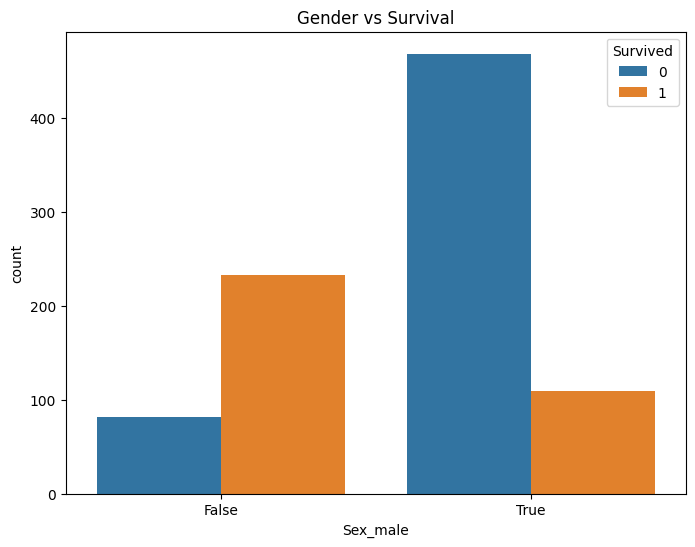

In [23]:
# Gender Vs SUrvival
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex_male', hue='Survived', data=df)

plt.title("Gender vs Survival")
plt.show()

This plot illustrates the survival rate based on gender. It clearly shows that a significantly higher proportion of females survived compared to males, highlighting gender as a strong determinant of survival.

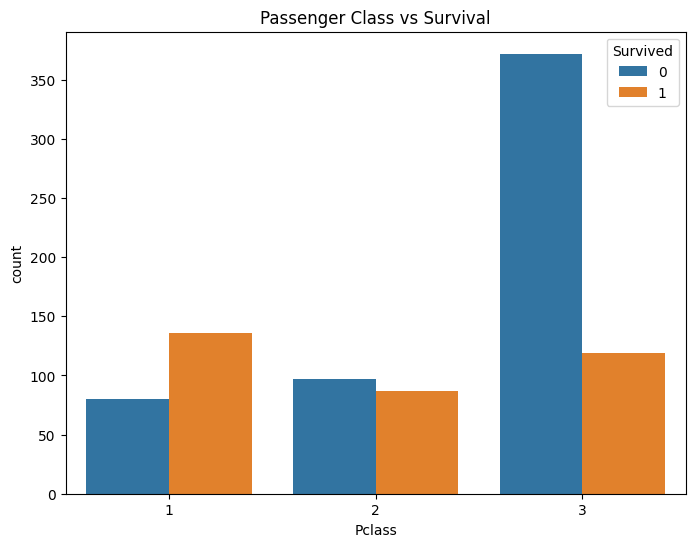

In [24]:
# Passenger Class Vs Survival
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Passenger Class vs Survival")
plt.show()

This plot reveals the survival rates across different passenger classes. Passengers in `Pclass 1` (first class) had a much higher survival rate than those in `Pclass 2` or `Pclass 3`, suggesting that social class played a role in survival.

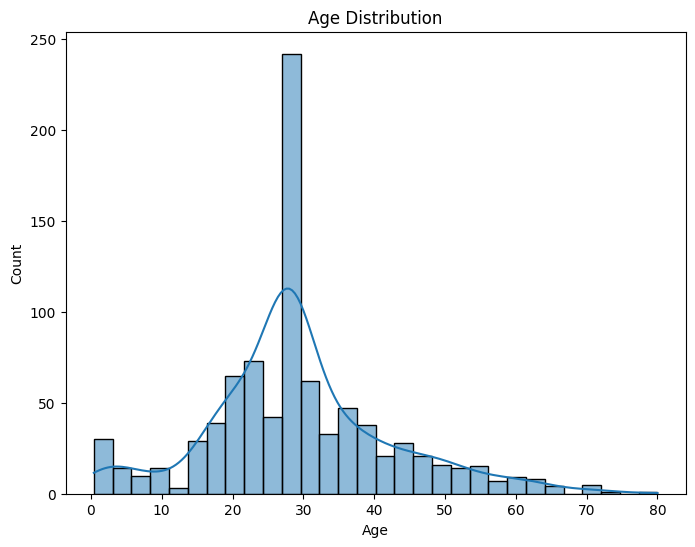

In [25]:
# Age Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True)

plt.title("Age Distribution")
plt.show()

This histogram displays the distribution of passenger ages. The majority of passengers were young to middle-aged adults, with fewer children and elderly individuals.

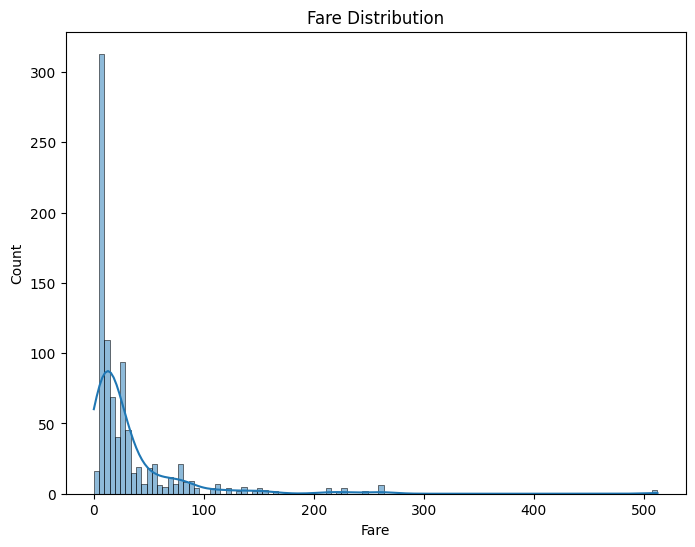

In [26]:
# Fare Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Fare'], kde=True)

plt.title("Fare Distribution")
plt.show()

This histogram shows the distribution of ticket fares. Most passengers paid lower fares, with a long tail indicating a few passengers paid very high fares. This distribution is highly right-skewed.

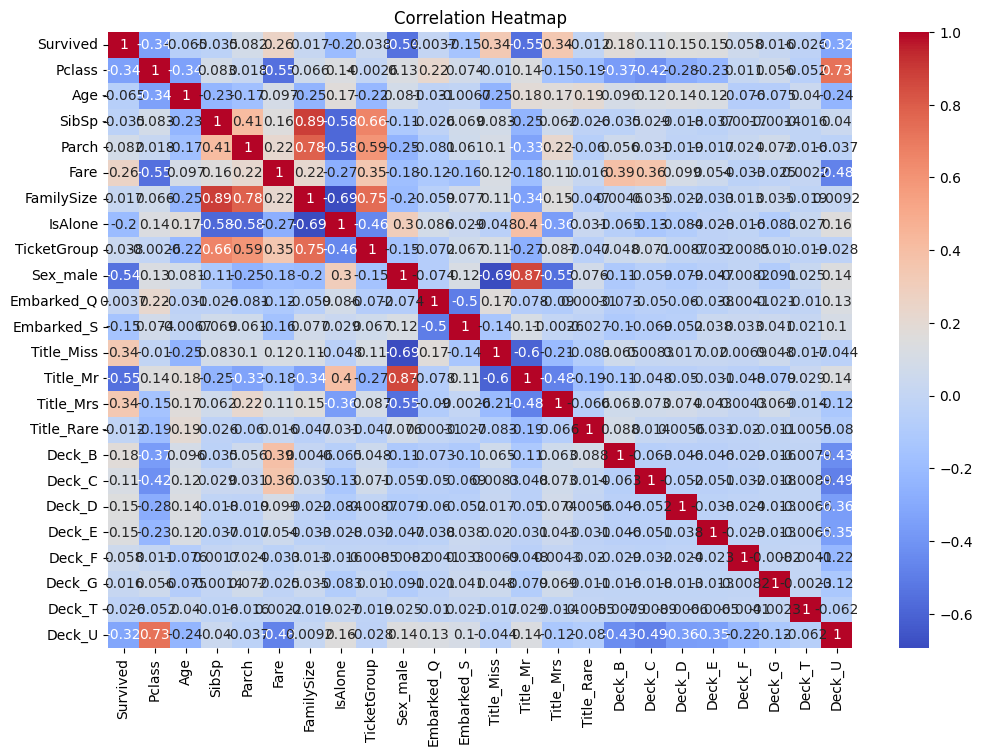

In [27]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

This heatmap visualizes the correlation between numerical features. It helps identify relationships between variables, such as the negative correlation between `Pclass` and `Fare`, meaning higher class tickets tend to be more expensive.

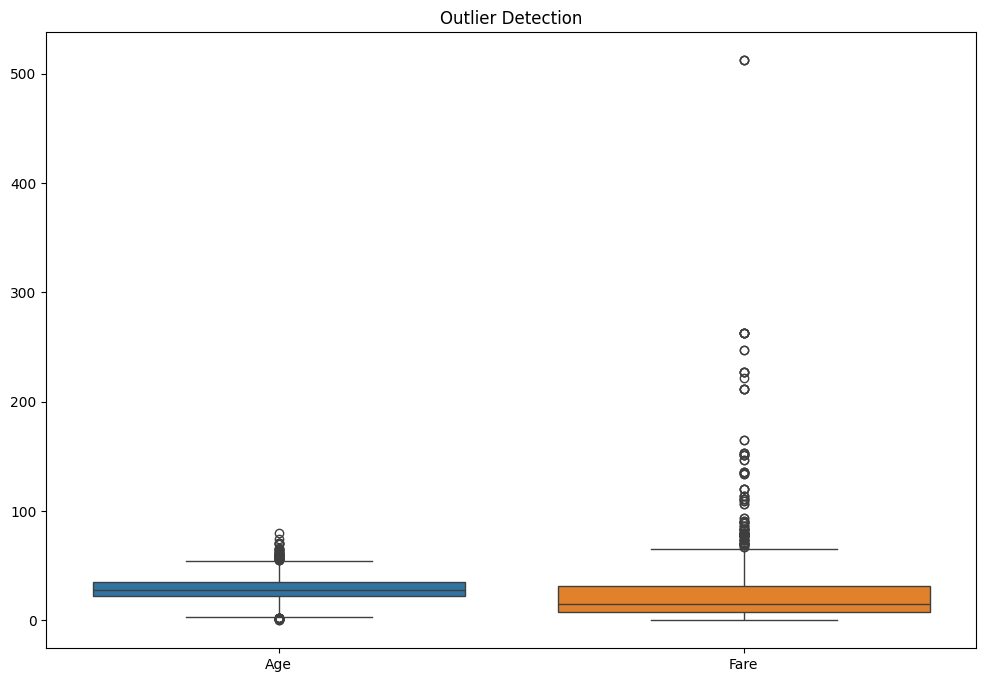

In [28]:
# Boxplot For Outlier Detection
plt.figure(figsize=(12,8))

sns.boxplot(data=df[['Age', 'Fare']])

plt.title("Outlier Detection")
plt.show()

This boxplot highlights the distribution and potential outliers in `Age` and `Fare`. While `Age` shows a relatively symmetric distribution with some outliers, `Fare` has many outliers, indicating a wide range of ticket prices, particularly on the higher end.

In [29]:
# Saving Cleaned Dataset
df.to_csv("cleaned_titanic.csv", index=False)

**Summary Findings**


*   More passengers unfortunately did not survive than did.
*   Female passengers had a significantly higher survival rate compared to males.
*   First-class passengers demonstrated a much higher survival rate than those in second or third class.
*   The majority of passengers were young to middle-aged adults, while ticket fares were predominantly lower, with a few exceptionally high values.
*   Initially, the Age, Cabin, and Embarked columns had missing values, which were subsequently imputed.
*   New features such as FamilySize, IsAlone, Title, Deck, and TicketGroup were engineered to enrich the dataset.
*   A negative correlation was observed between
passenger class and fare, suggesting higher classes generally paid more for their tickets.